In [7]:
import pandas as pd
import re
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from pprint import pprint
from itertools import chain
from sqlalchemy import create_engine
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy()) 
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [45]:
nsx_ds_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\abidmux_qc_AOZCK_full.csv')
all_ns6_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\all_ns6_multiqc.csv')
nsx_ss_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\ill_dmux_multiqc_ss_full.csv')

nsx_ss_multiqc['Protocol'] = 'Single'
nsx_ds_multiqc['Protocol'] = 'Double'

all_nsx_multiqc = pd.concat([nsx_ds_multiqc, nsx_ss_multiqc]).reset_index(drop=True)
all_nsx_multiqc['Platform'] = 'NovaSeqX'

# Remove diffs
diff_lib = set(all_nsx_multiqc.library_id) ^ set(all_ns6_multiqc.library_id) 
all_nsx_multiqc = all_nsx_multiqc[~all_nsx_multiqc['library_id'].isin(diff_lib)]
all_ns6_multiqc = all_ns6_multiqc[~all_ns6_multiqc['library_id'].isin(diff_lib)]
print(f'removed {diff_lib} from dataframes')

all_nsx_multiqc['Lane'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[0])
all_nsx_multiqc['Read Type'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else None)
diff_cols = set(all_ns6_multiqc.columns) ^ set(all_nsx_multiqc.columns)

all_nsx_multiqc = all_nsx_multiqc.drop(columns=diff_cols, errors='ignore')
all_ns6_multiqc = all_ns6_multiqc.drop(columns=diff_cols, errors='ignore')
print(f'removed {diff_cols} from dataframes')

all_multiqc_data = pd.concat([all_ns6_multiqc, all_nsx_multiqc]).reset_index(drop=True)

data_ns6 = all_ns6_multiqc
data_nsX = all_nsx_multiqc
data_ns6_ss = data_ns6[data_ns6['Protocol'] == 'Single']
data_nsX_ss = data_nsX[data_nsX['Protocol'] == 'Single']
data_ns6_ds = data_ns6[data_ns6['Protocol'] == 'Double']
data_nsX_ds = data_nsX[data_nsX['Protocol'] == 'Double']

removed {'LV7009026461', 'LV7008960913'} from dataframes
removed {'config_output_dir', 'Project', 'eDNA Concentration', 'suffix', 'fastq_id', 'qc_type'} from dataframes


Data validataion

In [46]:
assert set(all_nsx_multiqc.library_id) == set(all_ns6_multiqc.library_id)

In [47]:
sum_cols = ["fastqc_raw__Total Sequences", "fastqc_trimmed__Total Sequences"]
box_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"] 

Percentage of reads aligned out of total number of collapsed reads

In [48]:
print(data_ns6[data_ns6['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_ns6[data_ns6['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)
print(data_nsX[data_nsX['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_nsX[data_nsX['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)

KeyError: 'reads_aligned'

Same as above but per lane, single

In [49]:
protocol = 'Double'

g1 = \
    (data_ns6[
        (data_ns6['Read Type'] == 'collapsed') 
        & (data_ns6['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_ns6[
    (data_ns6['Read Type'] == 'collapsed') 
    & (data_ns6['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g1['reads_aligned'] = g1['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g2 = \
    (data_nsX[
        (data_nsX['Read Type'] == 'collapsed') 
        & (data_nsX['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_nsX[
    (data_nsX['Read Type'] == 'collapsed') 
    & (data_nsX['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g2['reads_aligned'] = g2['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g1.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeq6000')
g2.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeqX')

KeyError: "['reads_aligned'] not in index"

Scatter plot of total raw reads per library

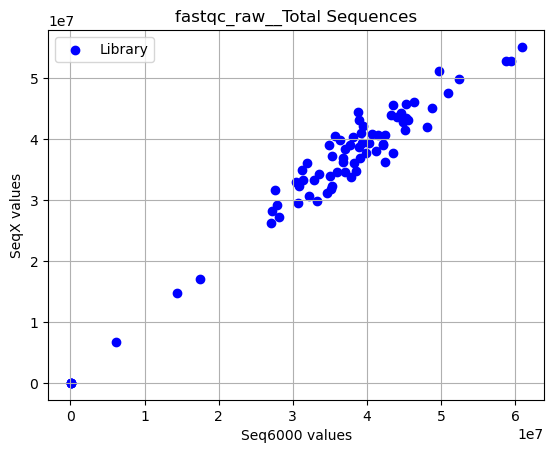

In [50]:
def scatter_plot(full_dataset, protocol, value_column):
    if protocol == "Single":
        filter = full_dataset["Protocol"] == "Single"
    
    elif protocol == "Double":
        filter = full_dataset["Protocol"] == "Double"
    
    elif protocol == "Both":
        filter = (full_dataset["Protocol"] == "Single") | (full_dataset["Protocol"] == "Double")
        
    else:
        raise Exception()
    
    full_dataset = full_dataset[filter]
    data_nsX = full_dataset[(full_dataset["Platform"] == "NovaSeqX") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L005")]
    data_ns6 = full_dataset[(full_dataset["Platform"] == "NovaSeq6") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L004")]
    
    x = data_nsX[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]
    y = data_ns6[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]

    # Create scatter plot
    plt.scatter(y, x, color='blue', label='Library', marker='o')
    
    # Customize the plot
    plt.title(value_column)  # Add a title
    plt.xlabel("Seq6000 values")  # Label for x-axis
    plt.ylabel("SeqX values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot(all_multiqc_data, "Double", "fastqc_raw__Total Sequences")

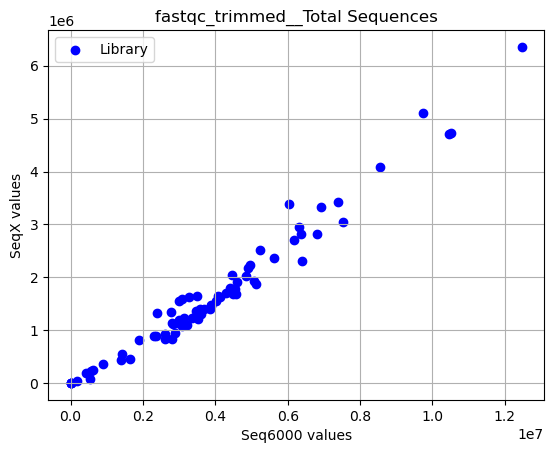

In [51]:
scatter_plot(all_multiqc_data, "Double", "fastqc_trimmed__Total Sequences")

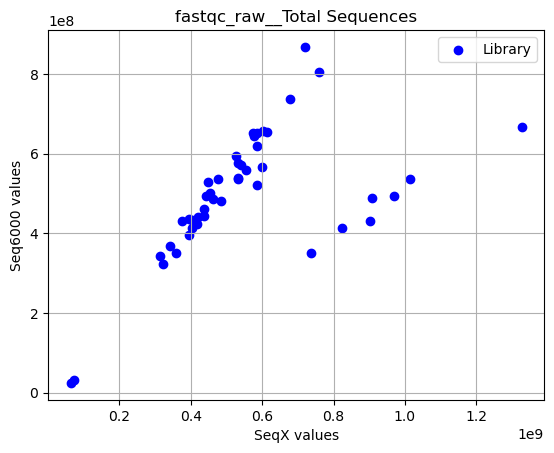

In [52]:
def scatter_plot(value):
    x = data_nsX[data_nsX["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]
    y = data_ns6[data_ns6["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]

    # Create scatter plot
    plt.scatter(x, y, color='blue', label='Library', marker='o')

    # Customize the plot
    plt.title("fastqc_raw__Total Sequences")  # Add a title
    plt.xlabel("SeqX values")  # Label for x-axis
    plt.ylabel("Seq6000 values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot("fastqc_raw__Total Sequences")

Compare raw output between lanes on NovaSeqX:

In [131]:

# Data selection and grouping
group_ns6 = data_ns6[(data_ns6["Protocol"] == "Double") & (data_ns6["Read Type"] == "R1") & (data_ns6["Lane"] == "L003")][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_ns6 = group_ns6[group_ns6["fastqc_raw__Total Sequences"] > 0].reset_index()

group_nsX = data_nsX[(data_nsX["Protocol"] == "Double") & (data_nsX["Lane"] == "L005") & (data_nsX["Read Type"] == "R1")][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_nsX = group_nsX[group_nsX["fastqc_raw__Total Sequences"] > 0].reset_index()

hover_template = "%{y}<extra></extra>"

# Create a single plot
fig = go.Figure()

# Add NS6 data
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the bar height
        name="NovaSeq6000",
        text=group_reset_ns6["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the text
        texttemplate="%{text:.2f}B",  # Format text as billions with 2 decimal places
        textposition="auto",  # Automatically position the text
        hovertemplate=hover_template
    )
)

# Add NSX data with formatted text as billions
fig.add_trace(
    go.Bar(
        x=group_reset_nsX["Lane"],
        y=group_reset_nsX["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the bar height
        name="NovaSeq X",
        text=group_reset_nsX["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the text
        texttemplate="%{text:.2f}B",  # Format text as billions with 2 decimal places
        textposition="auto",  # Automatically position the text
        hovertemplate=hover_template
    )
)

# Update layout
fig.update_layout(
    height=600,
    width=800,
    yaxis_title="Count (Billions)",
    yaxis_tickformat="~s",  # Format the y-axis scale to show large numbers with suffixes like 'B'
    barmode="group",  # Use grouped bars
    title="Total Raw Read Pairs",
    xaxis_title="Lane",
    legend_title="Dataset"
)

# Show the figure
fig.show()


In [59]:
difference = group_reset_ns6['fastqc_raw__Total Sequences'] - group_reset_nsX['fastqc_raw__Total Sequences'].iloc[0]
group_reset_ns6['abs_difference'] = difference

# Create a single plot
fig = go.Figure()


# Add NS6 data
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["abs_difference"],
        name="",
        hovertemplate=hover_template,
        showlegend=False  # Ensure mean appears in the legend
    )
)

mean_difference = group_reset_ns6['abs_difference'].mean()


# Overlay mean value as a dashed line
fig.add_trace(
    go.Scatter(
        x=group_reset_ns6["Lane"],
        y=[mean_difference] * len(group_reset_ns6),  # Mean line
        mode="lines",  # Add markers to the line
        name="Mean",
        line=dict(
            color="black",  # Set the color to re
            dash="dot",
            width=3       # Set line thickness
        ),
        showlegend=True  # Ensure mean appears in the legend
    )
)

# Add an annotation for the mean
fig.add_annotation(
    x=0.5,  # Adjust to position annotation centrally
    y=mean_difference + 1000000,
    xref="paper",
    yref="y",
    text=f"{mean_difference / 1_000_000:.2f}M",
    showarrow=False,
    font=dict(color="black", size=16)
)

# Update layout
fig.update_layout(
    height=600, width=800,
    yaxis_title="Difference",
    # yaxis_range=[0, 3e10],
    barmode="group",  # Use grouped bars
    title="R1 Sequences Count Difference",
    xaxis_title="Lane",
    legend_title="Dataset"
)

# Show the figure
fig.show()


In [60]:
difference = group_reset_ns6['abs_difference'] / group_reset_ns6['fastqc_raw__Total Sequences'] * 100
group_reset_ns6['percent_difference'] = difference

# Create the plot
fig = go.Figure()

# Add NS6 data as bars
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["percent_difference"],
        name="Percent Difference",
        hovertemplate="%{y:.2f}%<extra></extra>"
    )
)

mean_difference = group_reset_ns6['percent_difference'].mean()

# Overlay mean value as a dashed line
fig.add_trace(
    go.Scatter(
        x=group_reset_ns6["Lane"],
        y=[mean_difference] * len(group_reset_ns6),  # Mean line
        mode="lines",  # Add markers to the line
        name="Mean",
        line=dict(
            color="black",  # Set the color to re
            dash="dot",
            width=3       # Set line thickness
        ),
        showlegend=True  # Ensure mean appears in the legend
    )
)

# Add an annotation for the mean
fig.add_annotation(
    x=0.5,  # Adjust to position annotation centrally
    y=mean_difference +0.05,
    xref="paper",
    yref="y",
    text=f"{mean_difference:.2f}%",
    showarrow=False,
    font=dict(color="black", size=16)
)

# Update layout
fig.update_layout(
    height=600,
    width=800,
    yaxis_title="Percent Difference",
    title="R1 Sequence Count Percent Difference",
    xaxis_title="Lane",
    legend_title="Dataset"
)

fig.show()

Compare raw output between lanes on NovaSeq6:

<Axes: title={'center': 'NovaSeq6 Double'}, xlabel='Lane'>

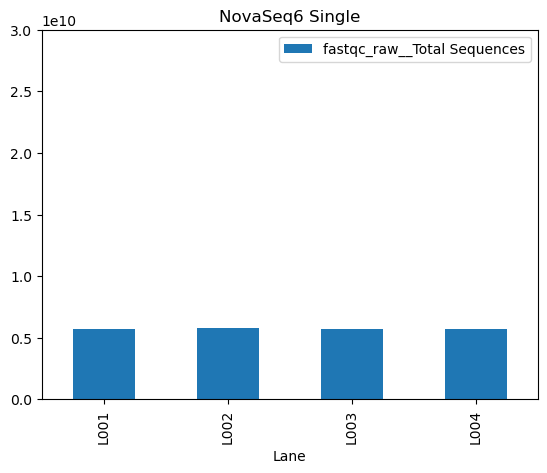

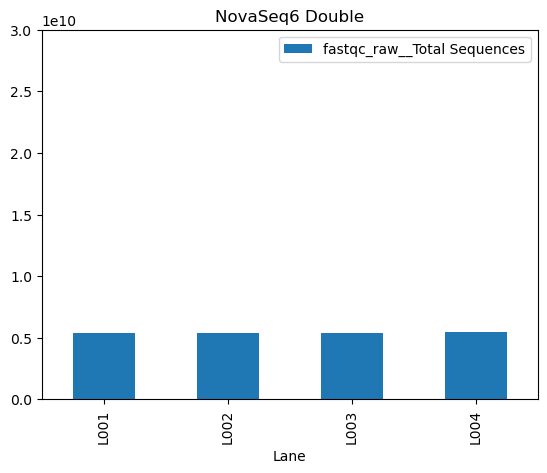

In [61]:
group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Single", ylim=(0, 3e10))

group = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Double", ylim=(0, 3e10))

Num of raw reads comparison single stranded

In [62]:
print("NovaSeqX: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (all_multiqc_data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (all_multiqc_data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 25.123163162
NovaSeq6000: 	 22.91257809


Num of raw reads comparison double stranded

In [63]:
print("NovaSeqX: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (all_multiqc_data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (all_multiqc_data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 5.345872524
NovaSeq6000: 	 21.632653832


Verify that all libraries have been sequenced on all lanes:

In [64]:
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")
        
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")

Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error


Percentage of collapsed out of total on NS6

In [66]:
data_ns6[data_ns6["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_ns6["fastqc_raw__Total Sequences"].sum() * 100

35.34489598026792

Percentage of collapsed out of total on NSX

In [71]:
print(data_nsX[data_nsX["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX["fastqc_raw__Total Sequences"].sum() * 100)
print(data_nsX_ds[data_nsX_ds["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX_ds["fastqc_raw__Total Sequences"].sum() * 100)
print(data_nsX_ss[data_nsX_ss["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX_ss["fastqc_raw__Total Sequences"].sum() * 100)

38.5215279307084
32.73477888115837
39.752870598341254


Percentage of discarded reads during fastp out of total reads

In [72]:
def get_total_after_fastp(platform):
    total_trimmed = 0
    for index, row in all_multiqc_data[all_multiqc_data["Platform"] == platform].iterrows():
        if row["Read Type"] == "collapsed":
            total_trimmed = total_trimmed + (row["fastqc_trimmed__Total Sequences"] * 2)
        else:
            pass
    
    return total_trimmed

def get_fastp_discarded(platform):
        before_fastp = all_multiqc_data[all_multiqc_data["Platform"] == platform]["fastqc_raw__Total Sequences"].sum()
        after = get_total_after_fastp(platform)
        diff = before_fastp - after

        return (diff / before_fastp) * 100
    
print("NovaSeqX: \t", get_fastp_discarded("NovaSeqX"))
print("NovaSeq6000: \t", get_fastp_discarded("NovaSeq6"))

NovaSeqX: 	 22.9569441385832
NovaSeq6000: 	 29.310208039464165


In [95]:
data_nsX_ds['fastqc_trimmed__Total Sequences'].sum() / data_nsX_ds['fastqc_raw__Total Sequences'].sum() * 100

38.991514736687726

Output from fastp single stranded

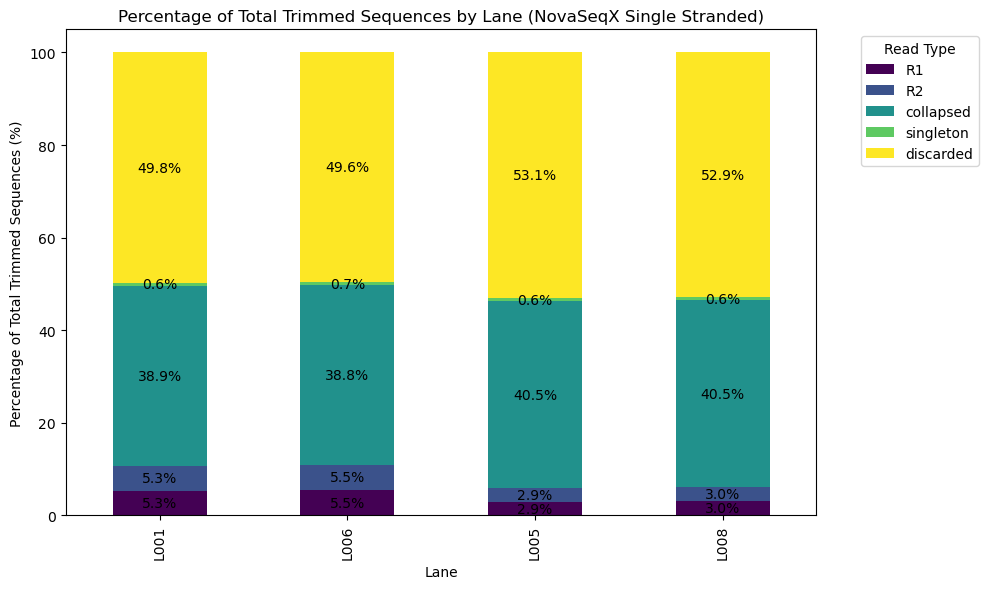

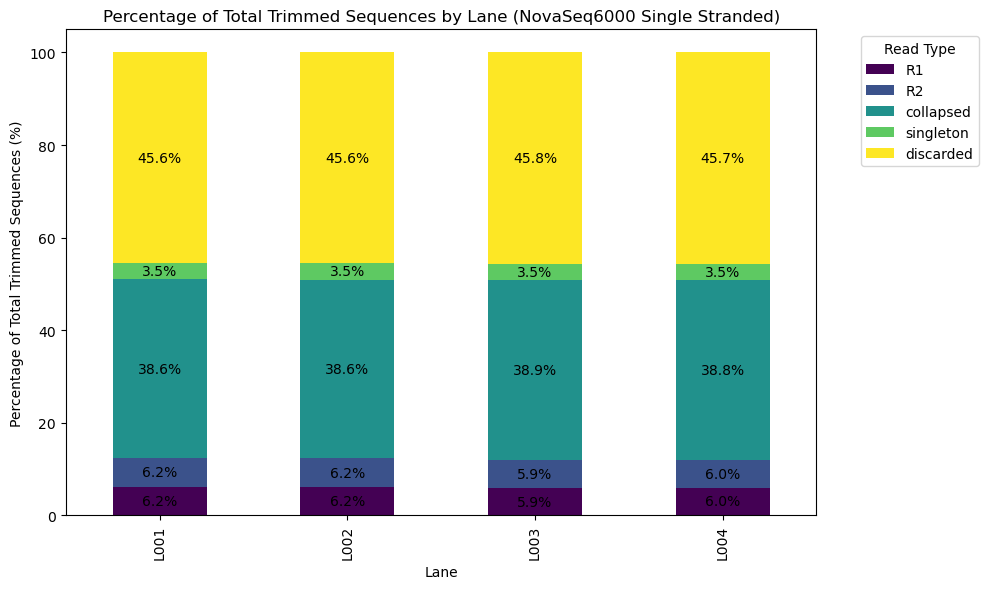

In [106]:
group = data_nsX[data_nsX["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")['fastqc_raw__Total Sequences'].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L006", "L005", "L008"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeqX Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_raw__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L002", "L003", "L004"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])


# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeq6000 Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Output from fastp Double stranded

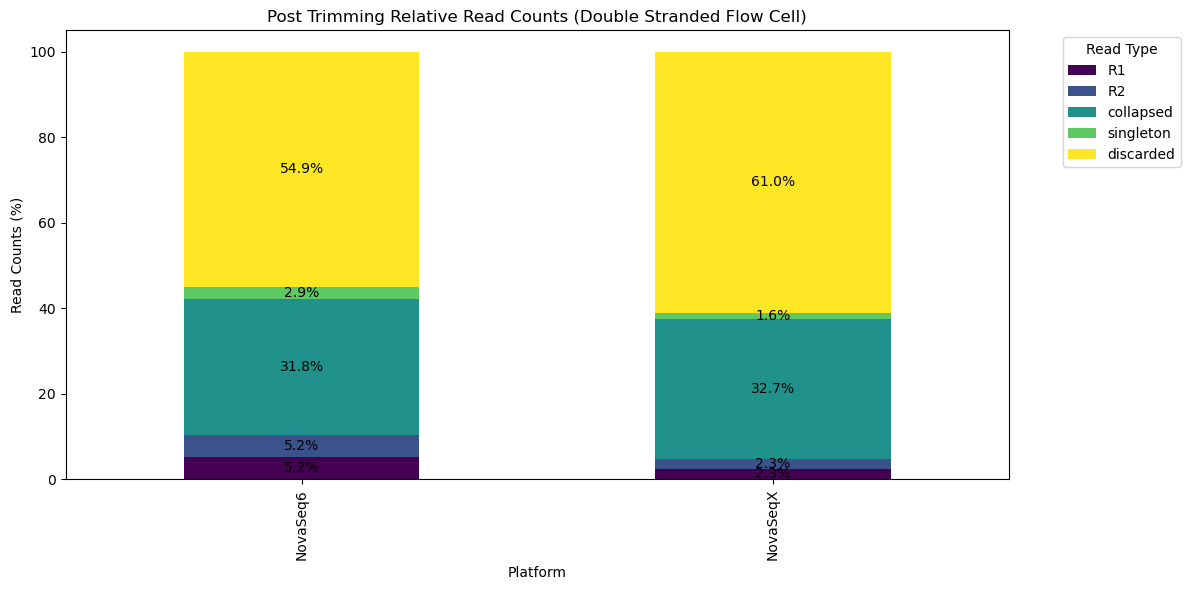

In [223]:
# Process NSX data (L005)
group_nsX = all_multiqc_data[all_multiqc_data["Protocol"] == "Double"][["Platform", "Read Type", "fastqc_trimmed__Total Sequences", "fastqc_raw__Total Sequences"]].groupby(["Platform", "Read Type"]).sum()
group_reset_nsX = group_nsX[group_nsX["fastqc_trimmed__Total Sequences"] > 0].reset_index()
group_reset_nsX["Total_Per_Lane"] = group_reset_nsX.groupby("Platform")["fastqc_raw__Total Sequences"].transform("sum")
group_reset_nsX["Percentage"] = (group_reset_nsX["fastqc_trimmed__Total Sequences"] / group_reset_nsX["Total_Per_Lane"]) * 100

pivot_nsX = group_reset_nsX.pivot(index="Platform", columns="Read Type", values="Percentage")
pivot_nsX["discarded"] = 100 - (pivot_nsX["R1"] + pivot_nsX["R2"] + pivot_nsX["collapsed"] + pivot_nsX["singleton"])


# Combine data for L004 and L005
pivot_nsX.index.name = "Platform"

# Plot combined data
ax = pivot_nsX.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")  # Display percentages with one decimal place

# Add labels and title
plt.title("Post Trimming Relative Read Counts (Double Stranded Flow Cell)")
plt.xlabel("Platform")
plt.ylabel("Read Counts (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Median sequence length double stranded collapsed

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\1215165101.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



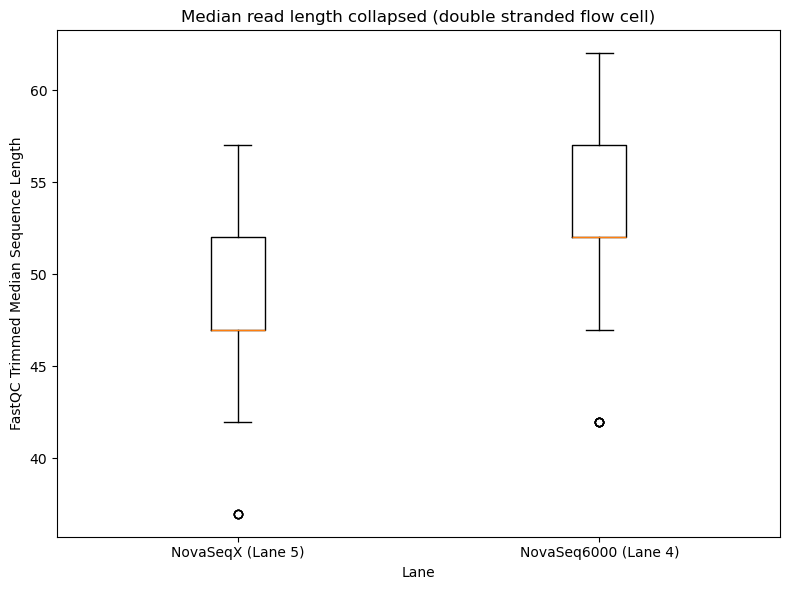

In [190]:
# Define the read type
read_type = "collapsed"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ds[
    (~data_nsX_ds[stat].isna()) 
    & (data_nsX_ds["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ds[
    (~data_ns6_ds[stat].isna()) 
    & (data_ns6_ds["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (double stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()


Median sequence length double stranded singleton

In [ ]:
sns.barplot(data=data_nsX_ds[(data_nsX_ds['Lane']=='L005') & (data_nsX_ds['Read Type']=='collapsed')],
            x="library_id",
            y='fastqc_trimmed__median_sequence_length')

<Axes: xlabel='library_id', ylabel='fastqc_trimmed__median_sequence_length'>

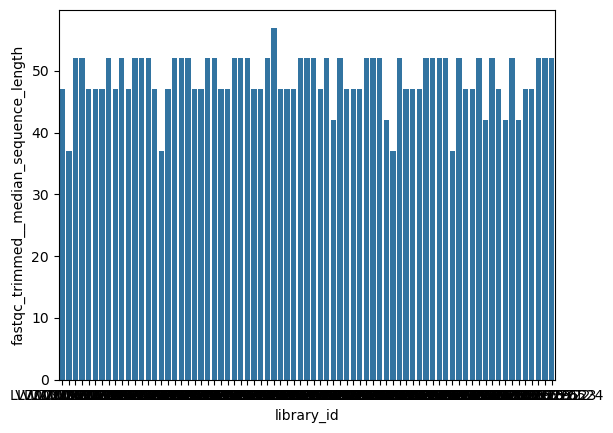

In [221]:
sns.barplot(data=data_nsX_ds[(data_nsX_ds['Lane']=='L005') & (data_nsX_ds['Read Type']=='collapsed')],
            x="library_id",
            y='fastqc_trimmed__median_sequence_length')

In [ ]:
# Filter the data for the specific conditions
filtered_data = data_nsX_ds[
    (data_nsX_ds['Lane'] == 'L005') & (data_nsX_ds['Read Type'] == 'collapsed')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L005 - Collapsed)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\255003208.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



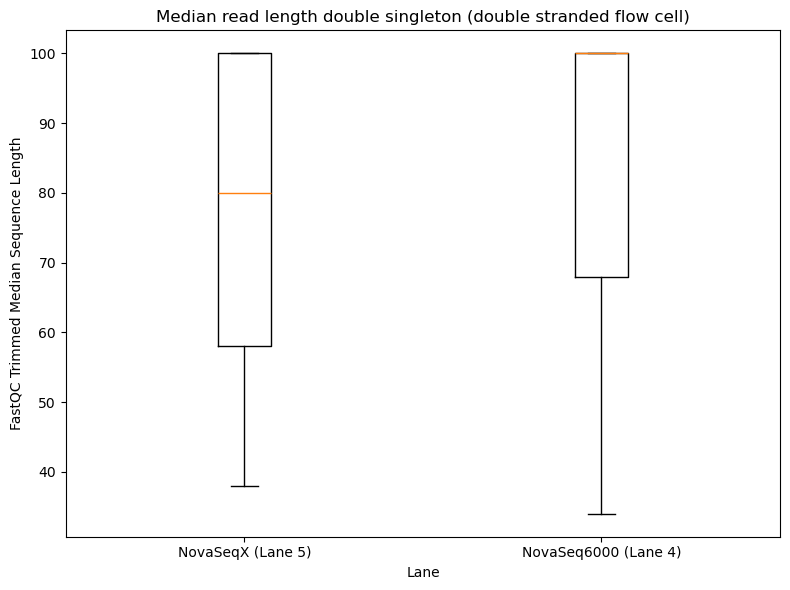

In [232]:
# Define the read type
read_type = "singleton"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ds[
    (~data_nsX_ds[stat].isna()) 
    & (data_nsX_ds["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ds[
    (~data_ns6_ds[stat].isna()) 
    & (data_ns6_ds["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length double {read_type} (double stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()


Median seq length collapsed single stranded

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\2537991095.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



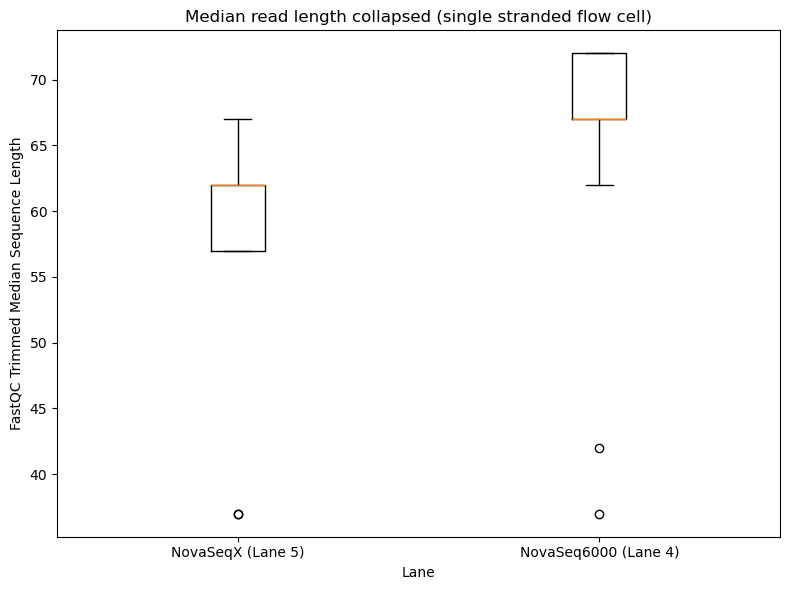

In [189]:
# Define the read type
read_type = "collapsed"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ss[
    (~data_nsX_ss[stat].isna()) 
    & (data_nsX_ss["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ss[
    (~data_ns6_ss[stat].isna()) 
    & (data_ns6_ss["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (single stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()

Median seq length singleton single stranded

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\729954140.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



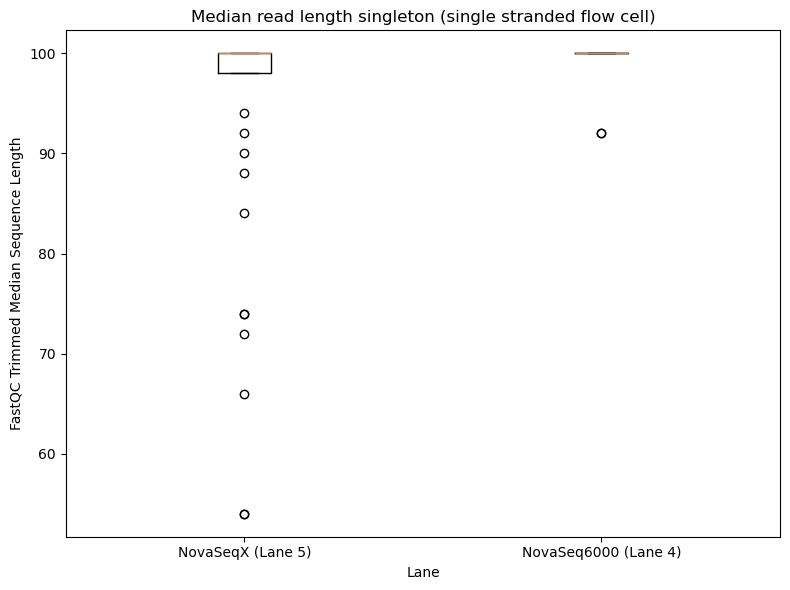

In [188]:
# Define the read type
read_type = "singleton"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ss[
    (~data_nsX_ss[stat].isna()) 
    & (data_nsX_ss["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ss[
    (~data_ns6_ss[stat].isna()) 
    & (data_ns6_ss["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (single stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()

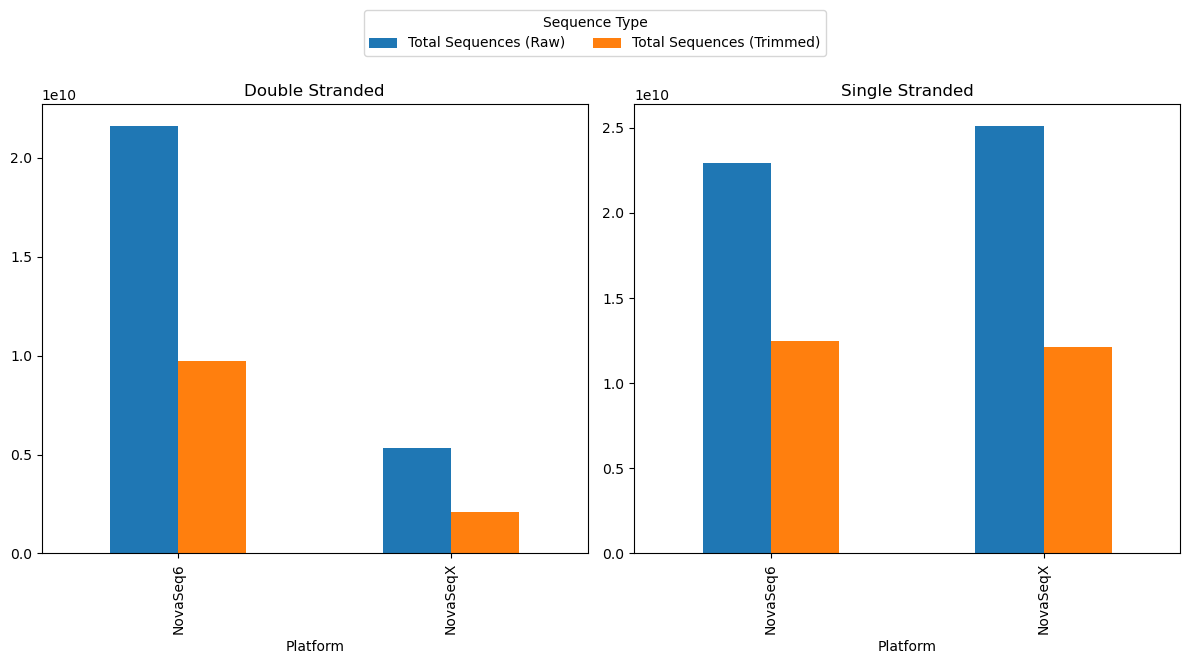

In [ ]:
def make_sum_plot_1(column1, column2, combined_df):
    combined_df[column1] = combined_df[column1].astype(float)
    combined_df[column2] = combined_df[column2].astype(float)

    double_df = combined_df[combined_df['Protocol'] == 'Double']
    single_df = combined_df[combined_df['Protocol'] == 'Single']
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')[column1].sum()

    trimmed_sum_double = double_df.groupby('Platform')[column2].sum()

    raw_sum_single = single_df.groupby('Platform')[column1].sum()

    trimmed_sum_single = single_df.groupby('Platform')[column2].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    })

    # Combine data into a DataFrame for easier plotting
    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    })

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
    combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

    plt.tight_layout()
    plt.show()
make_sum_plot_1('fastqc_raw__Total Sequences', 'fastqc_trimmed__Total Sequences', all_multiqc_data)

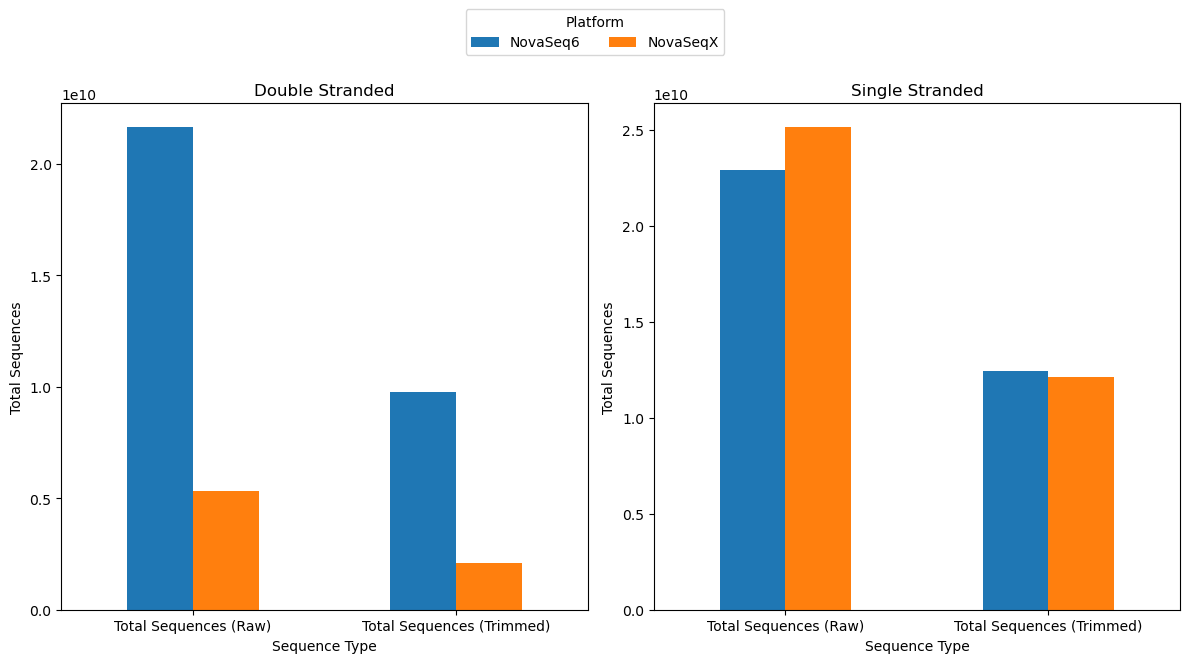

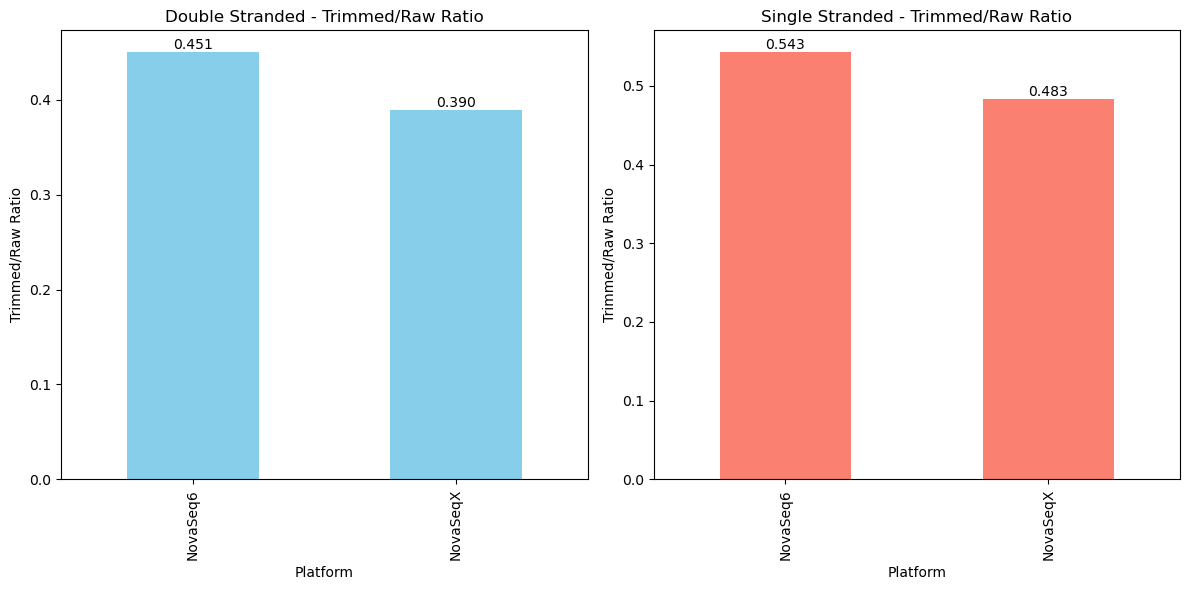

In [ ]:
def plot2(double_data, single_data):
    double_df = double_data
    single_df = single_data
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded
    combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
    ax[0].set_title("Double Stranded")
    ax[0].set_ylabel("Total Sequences")

    # Plot for Single Stranded
    combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
    ax[1].set_title("Single Stranded")
    ax[1].set_ylabel("Total Sequences")

    # Adding legend
    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

    plt.tight_layout()
    plt.show()

    
    # Calculate the ratio of trimmed to raw sequences
    ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
    ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded ratios
    ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
    ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
    ax[0].set_ylabel("Trimmed/Raw Ratio")
    ax[0].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
        ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    # Plot for Single Stranded ratios
    ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
    ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
    ax[1].set_ylabel("Trimmed/Raw Ratio")
    ax[1].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
        ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
plot2(all_multiqc_data[all_multiqc_data["Protocol"] == "Double"], all_multiqc_data[all_multiqc_data["Protocol"] == "Single"])

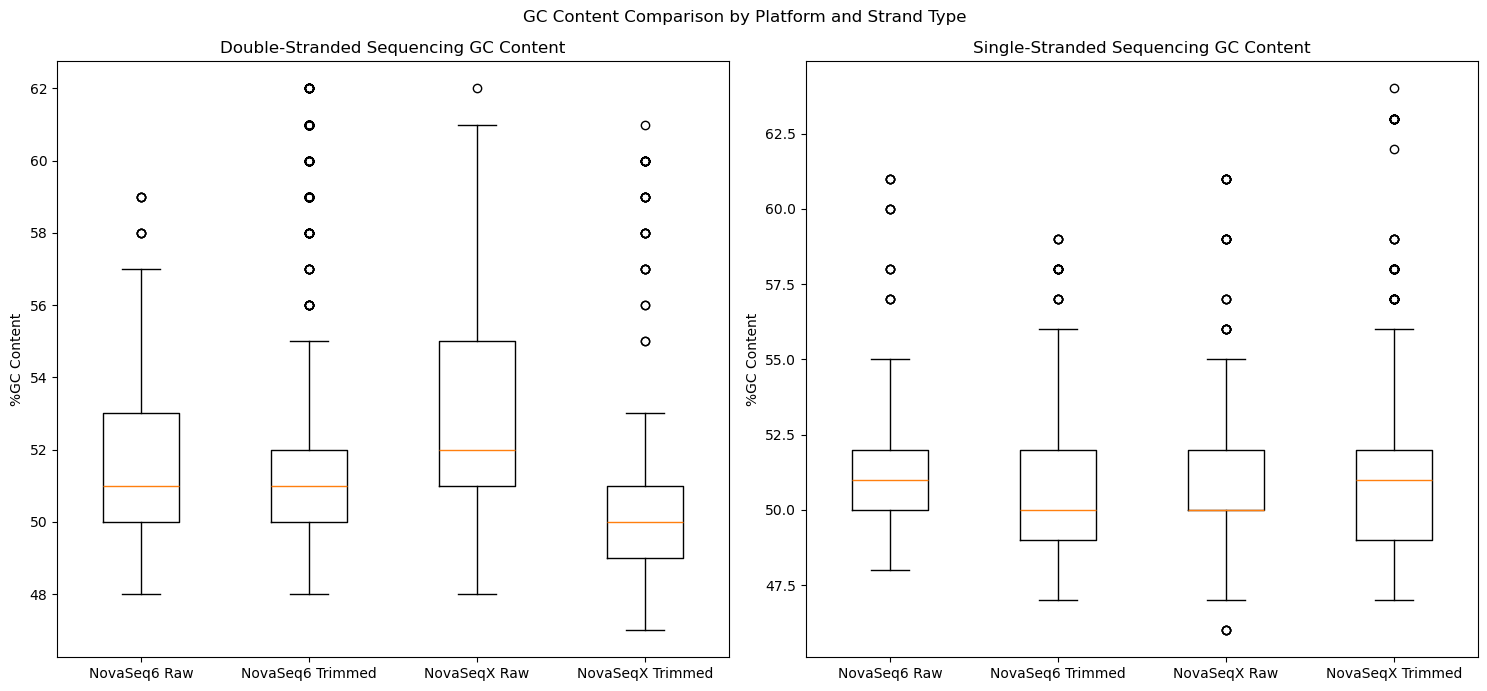

In [ ]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = all_multiqc_data["Platform"].unique()

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Double"], describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Single"], describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()